## Problem 1

Using the model from class, replace MobileNetV2 with ResNet50.

Evaluate:

- Training time
- Accuracy
- Model size


In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

dataset_path = tf.keras.utils.get_file(
    "flower_photos",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
    untar=True
)

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.


In [6]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)


In [8]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
base_model.trainable = False

In [11]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation="softmax")  # 5 flower classes
])

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Epoch 1/5


C:\Users\Gabri\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 87s 890ms/step - accuracy: 0.9751 - loss: 0.0747 - val_accuracy: 1.0000 - val_loss: 1.8338e-06
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 864ms/step - accuracy: 1.0000 - loss: 1.5548e-05 - val_accuracy: 1.0000 - val_loss: 5.9101e-07
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 858ms/step - accuracy: 1.0000 - loss: 1.2914e-05 - val_accuracy: 1.0000 - val_loss: 2.7870e-07
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 79s 861ms/step - accuracy: 1.0000 - loss: 1.3640e-05 - val_accuracy: 1.0000 - val_loss: 1.6274e-07
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 894ms/step - accuracy: 1.0000 - loss: 1.3480e-05 - val_accuracy: 1.0000 - val_loss: 9.1599e-08
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 689ms/step - accuracy: 1.0000 - loss: 9.1599e-08
Validation Accuracy: 1.0000


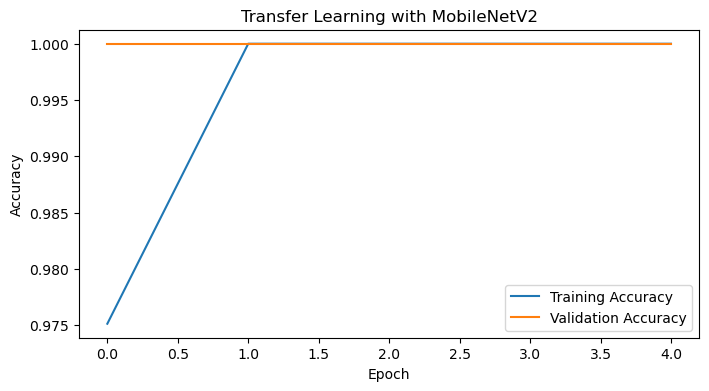

In [13]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)


loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation Accuracy: {accuracy:.4f}")


plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning with MobileNetV2")
plt.legend()
plt.show()


## Problem 2

Create a transfer learning model using the TensorFlow Flowers dataset and classify five flower species.


In [36]:
import tensorflow as tf

# 1. Load MNIST directly from Keras (no tfds required)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalize and reshape
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# 3. Create tf.data.Dataset objects
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(64)

In [37]:
!pip install importlib-resources

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

# 1. Load MNIST from tensorflow_datasets
(ds_train, ds_test), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    as_supervised=True,  # Returns (image, label) pairs
    with_info=True
)

# 2. Preprocessing function: cast to float32, normalize, and flatten
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Scale pixels to [0, 1]
    image = tf.reshape(image, (784,))           # Flatten 28x28 image to 784 vector
    return image, label

# 3. Apply preprocessing, batching, and prefetching
train_ds = ds_train.map(preprocess).batch(64).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).batch(64).prefetch(tf.data.AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Gabri\tensorflow_datasets\mnist\incomplete.4Y2PDJ_3.0.1\mnist-train.tfrecord-[0-9][0-9][0-9…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Gabri\tensorflow_datasets\mnist\incomplete.4Y2PDJ_3.0.1\mnist-test.tfrecord-[0-9][0-9][0-9]…

Dataset mnist downloaded and prepared to C:\Users\Gabri\tensorflow_datasets\mnist\3.0.1. Subsequent calls will reuse this data.


In [2]:
# Create Sequential Dense Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # 10 output classes (digits 0-9)
])

# Display model summary
model.summary()

C:\Users\Gabri\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the network
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

# Evaluate performance on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9896 - loss: 0.0338 - val_accuracy: 0.9732 - val_loss: 0.0876
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9913 - loss: 0.0288 - val_accuracy: 0.9756 - val_loss: 0.0880
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9923 - loss: 0.0234 - val_accuracy: 0.9706 - val_loss: 0.1099
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9931 - loss: 0.0207 - val_accuracy: 0.9752 - val_loss: 0.1001
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9944 - loss: 0.0171 - val_accuracy: 0.9748 - val_loss: 0.1034
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9945 - loss: 0.0158 - val_accuracy: 0.9713 - val_loss: 0.1181
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9951 - loss: 0.0141 - val_accuracy: 0.9756 - val_loss: 0.1002
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9958 - loss: 0.0124 - val_accurac

In [39]:
from PIL import Image, ImageOps

image_path = r"C:\Users\Gabri\OneDrive\Pictures\Screenshots 1\Screenshot (18).png"
img = Image.open(image_path)
img_gray = img.convert('L')


In [40]:
img_inverted = ImageOps.invert(img_gray)


In [41]:
img_resized = img_inverted.resize((28,28))

In [42]:
img_array = np.array(img_resized, dtype = np.float32) / 255.0

In [43]:
input_data = img_array.reshape(1, 784)

In [44]:
predictions = model.predict(input_data)
predicted_digit = np.argmax(predictions)
confidence = np.max(predictions) * 100

print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted Digit: 1
Confidence: 69.09%


In [ ]:
#It said that my 3 and 2 was a 5 and that my 4 was a 1. 
# I did have some help from google gemini with being able to test it with my own handwriting as well as configuring how to download mnst to use on the 
#neural networks
